# Метод опорных векторов (SVM)

**Цель работы:** изучить работу метода опорных векторов для задач классификации, познакомиться с ядрами и гиперпараметром C.

**Содержание работы:**
1. Линейно разделимые данные — SVM с линейным ядром, жёсткий зазор.
2. Линейно неразделимые данные — SVM с RBF-ядром.
3. Пересекающиеся классы — SVM с мягким зазором (poly ядро).

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles
from sklearn.svm import SVC
from sklearn import metrics

## 2. Линейно разделимые данные

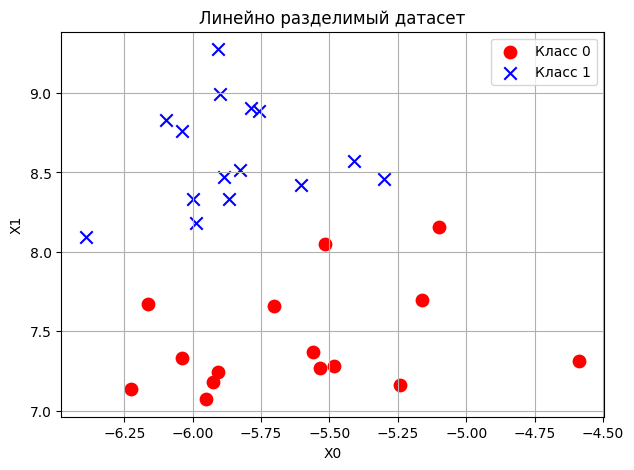

In [2]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], marker='o', c='r', s=80, label='Класс 0')
plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], marker='x', c='b', s=80, label='Класс 1')
plt.title('Линейно разделимый датасет')
plt.xlabel('X0')
plt.ylabel('X1')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
svm_linear = SVC(kernel='linear', C=100)
svm_linear.fit(X, y)

print('Коэффициенты:', svm_linear.coef_)
print('Свободный член (intercept):', svm_linear.intercept_)
print('Опорные векторы:')
print(svm_linear.support_vectors_)
print('Индексы опорных векторов:', svm_linear.support_)
print('Количество опорных векторов:', svm_linear.n_support_)

Коэффициенты: [[-2.49920793  6.14683189]]
Свободный член (intercept): [-64.2533988]
Опорные векторы:
[[-5.51629264  8.04763857]
 [-5.30025769  8.46071981]
 [-5.9879581   8.18112559]]
Индексы опорных векторов: [ 0  8 29]
Количество опорных векторов: [1 2]


### Граница решения и зазор

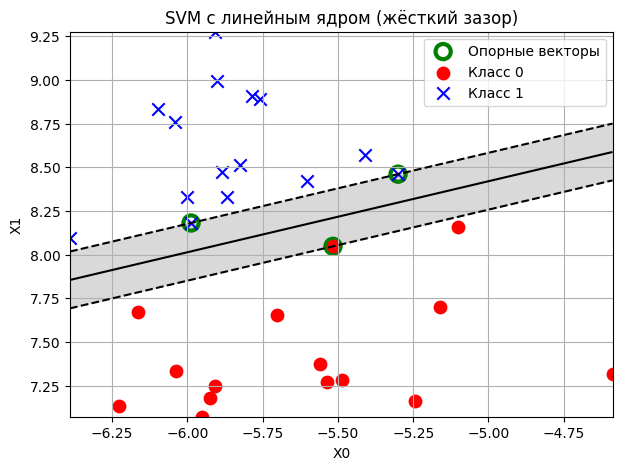

In [4]:
def plot_decision_regions(X, y, model, title=''):
    X0 = np.linspace(X[:, 0].min(), X[:, 0].max(), X.shape[0])
    X1 = np.linspace(X[:, 1].min(), X[:, 1].max(), X.shape[0])
    X0_grid, X1_grid = np.meshgrid(X0, X1)
    Z = model.decision_function(np.array([X0_grid.ravel(), X1_grid.ravel()]).T).reshape(X0_grid.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], alpha=0.15)
    plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                linewidth=3, facecolors='none', edgecolors='green', s=120, label='Опорные векторы')
    plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], marker='o', c='r', s=80, label='Класс 0')
    plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], marker='x', c='b', s=80, label='Класс 1')
    plt.title(title)
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_decision_regions(X, y, svm_linear, 'SVM с линейным ядром (жёсткий зазор)')

In [5]:
y_pred = svm_linear.predict(X)
print(f'Accuracy: {metrics.accuracy_score(y, y_pred):.4f}')
print('Матрица классификации:')
print(metrics.confusion_matrix(y, y_pred))

Accuracy: 1.0000
Матрица классификации:
[[15  0]
 [ 0 15]]


Модель идеально классифицирует линейно разделимые данные (accuracy = 1.0). Граница решения проходит ровно посередине зазора, опорные векторы лежат на его границах.

### Предсказание для новой точки

Значение decision function: -5.0313
Предсказанный класс: 0


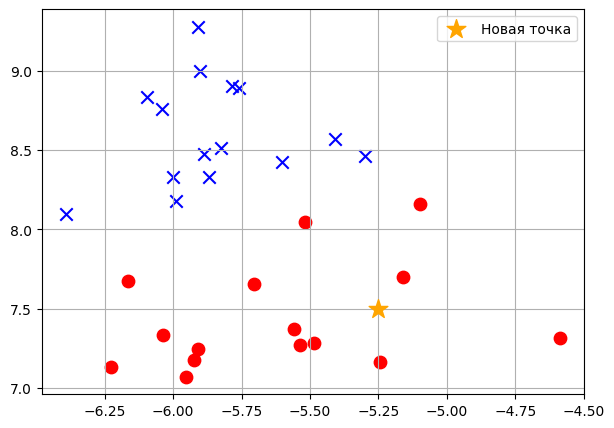

In [6]:
observation_new = [[-5.25, 7.5]]
print(f'Значение decision function: {svm_linear.decision_function(observation_new)[0]:.4f}')
print(f'Предсказанный класс: {svm_linear.predict(observation_new)[0]}')

plt.figure(figsize=(7, 5))
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=200, c='orange', label='Новая точка', zorder=5)
plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], marker='o', c='r', s=80)
plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], marker='x', c='b', s=80)
plt.legend()
plt.grid(True)
plt.show()

## 3. Линейно неразделимые данные (круги)

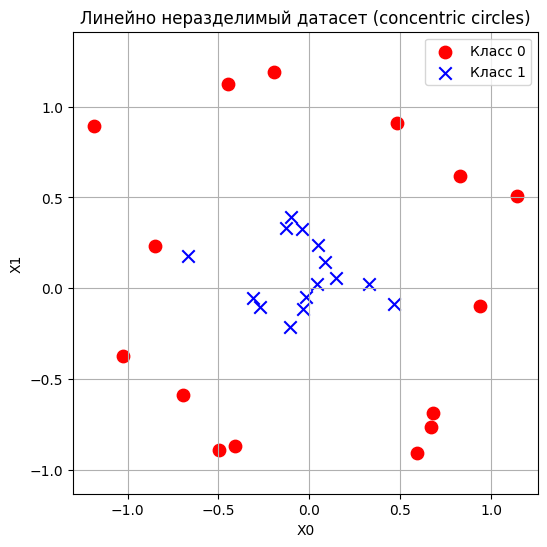

In [7]:
X2, y2 = make_circles(n_samples=30, random_state=5, factor=.1, noise=.2)

plt.figure(figsize=(6, 6))
plt.scatter(X2[:, 0][y2 == 0], X2[:, 1][y2 == 0], marker='o', c='r', s=80, label='Класс 0')
plt.scatter(X2[:, 0][y2 == 1], X2[:, 1][y2 == 1], marker='x', c='b', s=80, label='Класс 1')
plt.title('Линейно неразделимый датасет (concentric circles)')
plt.xlabel('X0')
plt.ylabel('X1')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

Количество опорных векторов: [6 2]


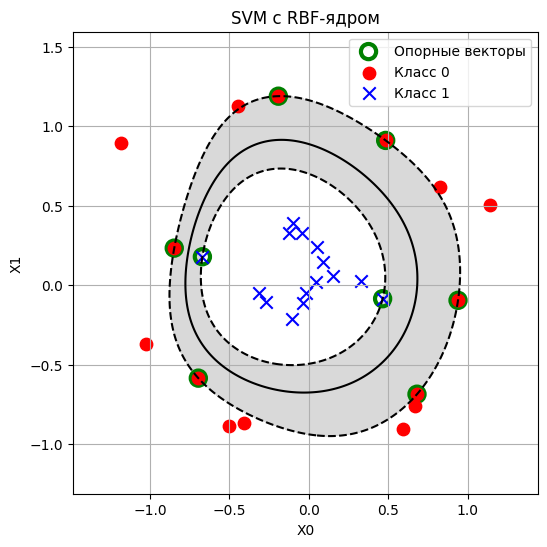

Accuracy: 1.0000


In [8]:
svm_rbf = SVC(kernel='rbf', C=100).fit(X2, y2)
print('Количество опорных векторов:', svm_rbf.n_support_)

X0_r = np.linspace(X2[:, 0].min() - 0.3, X2[:, 0].max() + 0.3, 300)
X1_r = np.linspace(X2[:, 1].min() - 0.3, X2[:, 1].max() + 0.3, 300)
X0_rg, X1_rg = np.meshgrid(X0_r, X1_r)
Z_r = svm_rbf.decision_function(np.array([X0_rg.ravel(), X1_rg.ravel()]).T).reshape(X0_rg.shape)

plt.figure(figsize=(6, 6))
plt.contourf(X0_rg, X1_rg, Z_r, colors='k', levels=[-1, 0, 1], alpha=0.15)
plt.contour(X0_rg, X1_rg, Z_r, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
plt.scatter(svm_rbf.support_vectors_[:, 0], svm_rbf.support_vectors_[:, 1],
            linewidth=3, facecolors='none', edgecolors='green', s=120, label='Опорные векторы')
plt.scatter(X2[:, 0][y2 == 0], X2[:, 1][y2 == 0], marker='o', c='r', s=80, label='Класс 0')
plt.scatter(X2[:, 0][y2 == 1], X2[:, 1][y2 == 1], marker='x', c='b', s=80, label='Класс 1')
plt.title('SVM с RBF-ядром')
plt.xlabel('X0')
plt.ylabel('X1')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

y_pred_rbf = svm_rbf.predict(X2)
print(f'Accuracy: {metrics.accuracy_score(y2, y_pred_rbf):.4f}')

RBF-ядро позволяет построить нелинейную границу решения в форме концентрических окружностей, эффективно разделяя линейно неразделимые данные.

## 4. Пересекающиеся классы (мягкий зазор)

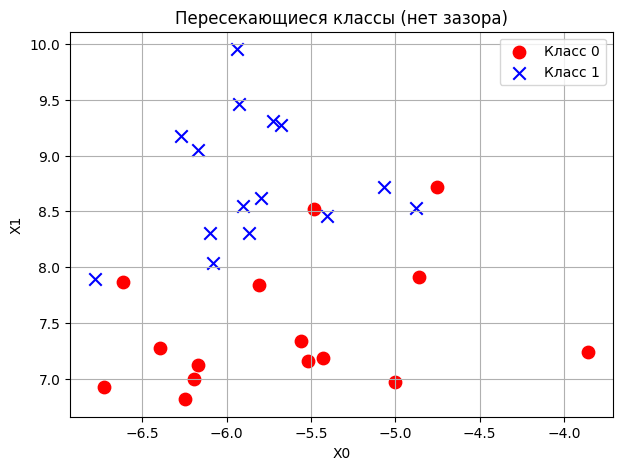

In [9]:
X3, y3 = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

plt.figure(figsize=(7, 5))
plt.scatter(X3[:, 0][y3 == 0], X3[:, 1][y3 == 0], marker='o', c='r', s=80, label='Класс 0')
plt.scatter(X3[:, 0][y3 == 1], X3[:, 1][y3 == 1], marker='x', c='b', s=80, label='Класс 1')
plt.title('Пересекающиеся классы (нет зазора)')
plt.xlabel('X0')
plt.ylabel('X1')
plt.legend()
plt.grid(True)
plt.show()

Количество опорных векторов: [9 9]


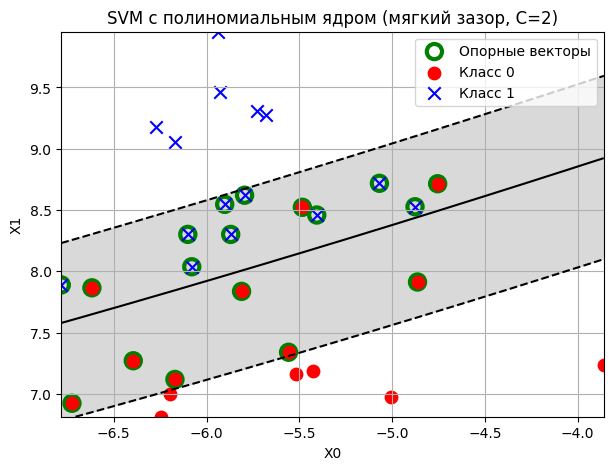

Accuracy: 0.9000
Матрица классификации:
[[12  3]
 [ 0 15]]


In [10]:
svm_poly = SVC(kernel='poly', degree=4, C=2).fit(X3, y3)
print('Количество опорных векторов:', svm_poly.n_support_)

plot_decision_regions(X3, y3, svm_poly, 'SVM с полиномиальным ядром (мягкий зазор, C=2)')

y_pred_poly = svm_poly.predict(X3)
print(f'Accuracy: {metrics.accuracy_score(y3, y_pred_poly):.4f}')
print('Матрица классификации:')
print(metrics.confusion_matrix(y3, y_pred_poly))

Уменьшение C создаёт более широкую полосу зазора, допуская часть точек внутрь — это **мягкий зазор** (soft margin). Модель допускает ошибки на обучении, но получает более устойчивую границу решения.

## Выводы

1. **Линейное ядро** идеально работает на линейно разделимых данных с жёстким зазором (C=100).
2. **RBF-ядро** эффективно разделяет линейно неразделимые данные (концентрические круги) за счёт нелинейной границы.
3. **Полиномиальное ядро** с малым C (мягкий зазор) справляется с пересекающимися классами, допуская ошибки для общей устойчивости.
4. Параметр C контролирует компромисс между шириной зазора и допустимыми нарушениями.